In [1]:
import sys
sys.path.append('C:/Users/Lenovo/Desktop/2019_ICM_E/tools/')
from PPPM import PPPM_datasets
from load_array import LoadArray
from mxnet import autograd,gluon,init
from animator import Animator

In [2]:
PPPM_data = PPPM_datasets(1000)

In [3]:
batch_size = 5
data_loader = LoadArray(PPPM_data,batch_size)

In [4]:
model = gluon.nn.Sequential()
model.add(
    gluon.nn.Dense(2),
    gluon.nn.Dropout(0.1), 
    gluon.nn.Dense(1)

)
model.initialize(init.Normal(sigma=0.01))
model

Sequential(
  (0): Dense(-1 -> 2, linear)
  (1): Dropout(p = 0.1, axes=())
  (2): Dense(-1 -> 1, linear)
)

In [5]:
loss_func = gluon.loss.L2Loss()
optimizer = gluon.Trainer(model.collect_params(),'sgd',{'learning_rate':0.0001})

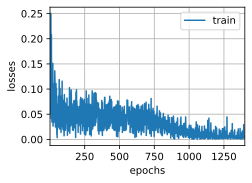

In [6]:
epochs = 1400
animator = Animator(xlabel='epochs',ylabel='losses',legend=['train'],xlim=[1,epochs])
for epoch in range(epochs):
    for feature, label in data_loader:
            with autograd.record():
                l = loss_func(model(feature),label)
                # print(feature,model(feature))
            l.backward()
            optimizer.step(batch_size)
            temp = l.mean().item()
    animator.add(epoch+1, (temp,))
        
                

In [7]:
model[0].weight.data()

array([[ 0.31434873, -0.27920765, -0.15085015, -0.18880758],
       [-0.31075794,  0.26576483,  0.14595886,  0.18557964]])

In [10]:
model[2].weight.data()

array([[-0.48616797,  0.47315028]])

In [24]:
from mxnet import np, npx
npx.set_np()
feature = np.array([[
0.0637,	0.9308,	0.91	,0.9833








]])
model(feature)



array([[0.8659673]])